# UFC Fight Outcome Predictor — XGBoost

### What makes this work
- **Fight-by-fight rolling stats** (last 3 and last 5 fights) capture recent form, not just career averages
- **Career stats** from the fighter database provide a stable baseline for fighters with thin UFC history
- **Split before swap** — test set stays in natural fight distribution for honest evaluation
- **Random 50% swap** on training set only — eliminates positional bias, model learns true feature relationships
- **Averaged inference** (both orderings) guarantees probabilities sum to exactly 1.0 for any matchup
- **Optuna tuning** finds optimal hyperparameters via Bayesian search
- **Dual AUC + calibration** — reports both balanced and natural distribution metrics
- **SHAP** explains which features drive each prediction

### Pipeline overview
```
Raw round-level stats → Fight-level aggregation → Rolling windows (3 & 5 fight) →
Pair fighters → Add career stats → Diff features → Train/test split →
Swap training set only → Optuna tuning → XGBoost → Dual evaluation
```

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("XGBoost:", xgb.__version__)

# ── Google Colab: mount Drive and set data paths ──────────────────────────────
# Uncomment if running on Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/ufc/'

# Local paths (adjust to your setup)
DATA_DIR = './'

STATS_PATH          = DATA_DIR + 'ufc_fight_stats.csv'
RESULTS_PATH        = DATA_DIR + 'ufc_fight_results_with_odds.csv'
FIGHTER_STATS_PATH  = DATA_DIR + 'ufc-fighters-statistics.csv'

XGBoost: 3.2.0


## 2. Parse Fight Stats

The raw data has one row per fighter per round. We parse `X of Y` strings into landed/attempted, convert control time to seconds, then aggregate across rounds into one record per fighter per fight.

In [2]:
def clean_name(n):
    return str(n).lower().strip().replace('.', '').replace("'", "")

def parse_of(series, landed_name, att_name):
    """Parse 'X of Y' strings into two numeric columns."""
    landed = series.str.extract(r'(\d+)\s+of\s+\d+')[0].astype(float)
    att    = series.str.extract(r'\d+\s+of\s+(\d+)')[0].astype(float)
    return landed.rename(landed_name), att.rename(att_name)

def ctrl_to_sec(s):
    """Convert MM:SS control time string to seconds."""
    try:
        m, sec = str(s).split(':')
        return int(m) * 60 + int(sec)
    except:
        return 0

def safe_div(a, b):
    return np.where(b > 0, a / b, 0.0)

# ── Load raw stats ────────────────────────────────────────────────────────────
stats = pd.read_csv(STATS_PATH).dropna(subset=['FIGHTER'])
stats['EVENT'] = stats['EVENT'].str.strip()
stats['BOUT']  = stats['BOUT'].str.strip()

# Parse all 'X of Y' columns
of_columns = {
    'SIG.STR.':   ('sig_landed',    'sig_att'),
    'TOTAL STR.': ('total_landed',  'total_att'),
    'TD':         ('td_landed',     'td_att'),
    'HEAD':       ('head_landed',   'head_att'),
    'BODY':       ('body_landed',   'body_att'),
    'LEG':        ('leg_landed',    'leg_att'),
    'DISTANCE':   ('dist_landed',   'dist_att'),
    'CLINCH':     ('clinch_landed', 'clinch_att'),
    'GROUND':     ('ground_landed', 'ground_att'),
}
for col, (l, a) in of_columns.items():
    stats[l], stats[a] = parse_of(stats[col], l, a)

stats['ctrl_sec'] = stats['CTRL'].apply(ctrl_to_sec)
for c in ['KD', 'SUB.ATT', 'REV.']:
    stats[c] = pd.to_numeric(stats[c], errors='coerce').fillna(0)
stats['FIGHTER'] = stats['FIGHTER'].apply(clean_name)

# ── Aggregate rounds → one row per fighter per fight ──────────────────────────
agg_cols = [
    'sig_landed', 'sig_att', 'total_landed', 'total_att',
    'td_landed', 'td_att', 'head_landed', 'head_att',
    'body_landed', 'body_att', 'leg_landed', 'leg_att',
    'dist_landed', 'dist_att', 'clinch_landed', 'clinch_att',
    'ground_landed', 'ground_att', 'ctrl_sec', 'KD', 'SUB.ATT', 'REV.'
]
fight_level = stats.groupby(['EVENT', 'BOUT', 'FIGHTER'])[agg_cols].sum().reset_index()

# Derived accuracy rates per fight
fight_level['sig_acc']     = safe_div(fight_level['sig_landed'],    fight_level['sig_att'])
fight_level['td_acc']      = safe_div(fight_level['td_landed'],     fight_level['td_att'])
fight_level['head_rate']   = safe_div(fight_level['head_landed'],   fight_level['sig_landed'])
fight_level['body_rate']   = safe_div(fight_level['body_landed'],   fight_level['sig_landed'])
fight_level['leg_rate']    = safe_div(fight_level['leg_landed'],    fight_level['sig_landed'])
fight_level['dist_rate']   = safe_div(fight_level['dist_landed'],   fight_level['total_landed'])
fight_level['clinch_rate'] = safe_div(fight_level['clinch_landed'], fight_level['total_landed'])
fight_level['ground_rate'] = safe_div(fight_level['ground_landed'], fight_level['total_landed'])

print(f"Fight-level records: {fight_level.shape}")
fight_level.head(3)

Fight-level records: (17306, 33)


,EVENT,BOUT,FIGHTER,sig_landed,sig_att,total_landed,total_att,td_landed,td_att,head_landed,...,SUB.ATT,REV.,sig_acc,td_acc,head_rate,body_rate,leg_rate,dist_rate,clinch_rate,ground_rate
0,Ortiz vs Shamrock 3: The Final Chapter,Jason MacDonald vs. Ed Herman,ed herman,2.0,2.0,5.0,5.0,1.0,2.0,0.0,...,0.0,1.0,1.000000,0.5,0.0,0.0,1.0,0.400000,0.000000,0.000000
1,Ortiz vs Shamrock 3: The Final Chapter,Jason MacDonald vs. Ed Herman,jason macdonald,5.0,7.0,14.0,16.0,0.0,1.0,4.0,...,2.0,1.0,0.714286,0.0,0.8,0.0,0.2,0.142857,0.000000,0.214286
2,Ortiz vs Shamrock 3: The Final Chapter,Kendall Grove vs. Chris Price,chris price,5.0,10.0,7.0,12.0,0.0,0.0,2.0,...,0.0,1.0,0.500000,0.0,0.4,0.6,0.0,0.285714,0.428571,0.000000


## 3. Join Outcomes & Sort Chronologically

In [3]:
results = pd.read_csv(RESULTS_PATH)
results['EVENT'] = results['EVENT'].str.strip()
results['BOUT']  = results['BOUT'].str.strip()

results[['f1', 'f2']] = results['BOUT'].str.split(' vs. ', expand=True)
results['f1'] = results['f1'].str.strip().apply(clean_name)
results['f2'] = results['f2'].str.strip().apply(clean_name)

odds_cols = ['f1_open_odds', 'f2_open_odds', 'f1_close_odds', 'f2_close_odds']
for col in odds_cols:
    if col not in results.columns:
        results[col] = np.nan
    results[col] = pd.to_numeric(results[col], errors='coerce')

if 'odds_inferred' not in results.columns:
    results['odds_inferred'] = False
results['odds_inferred'] = results['odds_inferred'].astype(int)

decisive = results[results['OUTCOME'].isin(['W/L', 'L/W'])][
    ['EVENT', 'BOUT', 'f1', 'f2', 'OUTCOME', 'odds_inferred'] + odds_cols
].copy()
decisive['outcome'] = (decisive['OUTCOME'] == 'W/L').astype(int)  # 1 = f1 won

fl = fight_level.merge(
    decisive[['EVENT', 'BOUT', 'f1', 'f2', 'outcome', 'odds_inferred'] + odds_cols],
    on=['EVENT', 'BOUT'],
    how='inner'
)
fl['is_f1']    = fl['FIGHTER'] == fl['f1']
fl['won']      = np.where(fl['is_f1'], fl['outcome'], 1 - fl['outcome'])
fl['opponent'] = np.where(fl['is_f1'], fl['f2'], fl['f1'])
fl['open_odds'] = np.where(fl['is_f1'], fl['f1_open_odds'], fl['f2_open_odds'])
fl['close_odds'] = np.where(fl['is_f1'], fl['f1_close_odds'], fl['f2_close_odds'])

# Raw data is newest-first; reverse to get oldest-first for rolling
event_order = results[['EVENT']].drop_duplicates().reset_index(drop=True)
event_order['event_idx'] = event_order.index.max() - event_order.index  # 0 = oldest
fl = fl.merge(event_order, on='EVENT', how='left')
fl = fl.sort_values(['FIGHTER', 'event_idx']).reset_index(drop=True)

print(f"Decisive fights joined: {fl.shape}")
print(f"Win rate: {fl['won'].mean():.3f}  (should be exactly 0.5)")
print(f"Rows with odds: {fl['open_odds'].notna().sum()}/{len(fl)} fighter rows")
print(f"Inferred odds rows: {fl['odds_inferred'].sum()}/{len(fl)} fighter rows")


Decisive fights joined: (17000, 47)
Win rate: 0.500  (should be exactly 0.5)
Rows with odds: 17000/17000 fighter rows
Inferred odds rows: 7134/17000 fighter rows


## 4. Rolling Features

For each fighter, compute rolling means over their **last 3 and last 5 fights** for every stat. The `.shift(1)` prevents data leakage — the rolling window for fight N uses only fights 1..N-1.

In [4]:
roll_base = [
    'sig_landed', 'sig_att', 'sig_acc', 'td_landed', 'td_att', 'td_acc',
    'head_rate', 'body_rate', 'leg_rate', 'dist_rate', 'clinch_rate', 'ground_rate',
    'ctrl_sec', 'KD', 'SUB.ATT', 'REV.', 'won'
]

for w in [3, 5]:
    for feat in roll_base:
        fl[f'roll{w}_{feat}'] = (
            fl.groupby('FIGHTER')[feat]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        )

fl['n_prior_fights'] = fl.groupby('FIGHTER').cumcount()
fl_model = fl[fl['n_prior_fights'] >= 1].copy()  # need at least 1 prior fight

roll_cols = [c for c in fl_model.columns if c.startswith('roll')]
print(f"Rolling features added: {len(roll_cols)}")
print(f"Fight records for modelling: {len(fl_model)}")
print()
# Sanity check: Jon Jones rolling stats in chronological order
jj = fl_model[fl_model['FIGHTER'] == 'jon jones'][
    ['EVENT', 'won', 'roll5_sig_landed', 'roll5_td_acc', 'roll3_won', 'roll5_won']
].head(6)
print("Jon Jones rolling stats (chronological):")
print(jj.to_string(index=False))

Rolling features added: 34
Fight records for modelling: 14334

Jon Jones rolling stats (chronological):
                                    EVENT  won  roll5_sig_landed  roll5_td_acc  roll3_won  roll5_won
              UFC 94: St-Pierre vs Penn 2    1         42.000000      0.400000   1.000000       1.00
                                  UFC 100    1         43.500000      0.550000   1.000000       1.00
The Ultimate Fighter: Heavyweights Finale    0         37.333333      0.366667   1.000000       1.00
                  UFC Live: Vera vs Jones    1         39.000000      0.525000   0.666667       0.75
           UFC Live: Jones vs Matyushenko    1         33.400000      0.553333   0.666667       0.80
                UFC 126: Silva vs Belfort    1         28.000000      0.673333   0.666667       0.80


## 5. Load Career Stats

Career stats from the fighter database act as a stable baseline — critical for fighters with few UFC fights where rolling averages are noisy.

In [5]:
fs = pd.read_csv(FIGHTER_STATS_PATH).drop(columns=['nickname'])

num_cols = fs.select_dtypes('float').columns
fs[num_cols] = fs[num_cols].fillna(fs[num_cols].median())

fs['date_of_birth'] = pd.to_datetime(fs['date_of_birth'], errors='coerce')
today = pd.Timestamp.today()
fs['age'] = fs['date_of_birth'].apply(
    lambda d: today.year - d.year - ((today.month, today.day) < (d.month, d.day))
    if pd.notnull(d) else np.nan
)
fs = fs.drop(columns=['date_of_birth'])
fs['age'] = fs['age'].fillna(fs['age'].median())
fs['stance'] = fs['stance'].fillna('Unknown')
fs = pd.get_dummies(fs, columns=['stance'], prefix='stance', dtype=int)
fs['name'] = fs['name'].apply(clean_name)

career_cols = [c for c in fs.columns if c != 'name']
print(f"Career features: {len(career_cols)}")
print(f"Fighters in database: {len(fs)}")

Career features: 21
Fighters in database: 4489


## 6. Build Paired Matchup Dataset

For each fight we create one row with both fighters' rolling stats and career stats side-by-side, plus difference features (self − opponent) for every stat.

**Key design:** We split into train/test *before* swapping, then swap only the training set. This means:
- **Training set:** 50/50 balanced, no positional bias → model learns true feature relationships
- **Test set:** natural fight distribution (favorite wins ~65%) → honest real-world evaluation

In [6]:
from sklearn.model_selection import train_test_split

# Self-join: match each fighter row with their opponent's row in the same fight
current_odds_cols = ['open_odds', 'close_odds']
fight_level_cols = ['odds_inferred']
fighter_view = fl_model[['EVENT', 'BOUT', 'FIGHTER', 'opponent', 'won', 'event_idx'] + roll_cols + current_odds_cols + fight_level_cols].copy()

side_specific_cols = roll_cols + current_odds_cols
opp_view = fighter_view[['EVENT', 'BOUT', 'FIGHTER'] + side_specific_cols].copy()
opp_view = opp_view.rename(columns={c: f'{c}_opp' for c in side_specific_cols})
opp_view = opp_view.rename(columns={'FIGHTER': 'opponent'})

self_view = fighter_view.rename(columns={c: f'{c}_self' for c in side_specific_cols})
paired = self_view.merge(opp_view, on=['EVENT', 'BOUT', 'opponent'], how='inner')

# Add career stats for fighter and opponent
paired = paired.merge(
    fs.rename(columns={c: f'career_{c}' for c in career_cols} | {'name': 'name'}),
    left_on='FIGHTER', right_on='name', how='left'
).drop(columns=['name'])
paired = paired.merge(
    fs.rename(columns={c: f'opp_career_{c}' for c in career_cols} | {'name': 'name'}),
    left_on='opponent', right_on='name', how='left'
).drop(columns=['name'])

# Odds are fully populated by ufc_fight_results_with_odds.csv. Keep XGBoost missing-safe anyway.
paired = paired.dropna(subset=[c for c in paired.columns if c not in [f'{x}_self' for x in current_odds_cols] + [f'{x}_opp' for x in current_odds_cols]])


# Column groups
self_cols     = [c for c in paired.columns if c.endswith('_self')]
opp_roll_cols = [c for c in paired.columns if c.endswith('_opp') and not c.startswith('opp_career')]
career_self   = [c for c in paired.columns if c.startswith('career_')]
career_opp    = [c for c in paired.columns if c.startswith('opp_career_')]

# Diff features
for col in side_specific_cols:
    paired[f'diff_{col}'] = paired[f'{col}_self'] - paired[f'{col}_opp']
for s, o in zip(career_self, career_opp):
    paired[f'diff_{s[7:]}'] = paired[s] - paired[o]

paired_original = paired.copy()

diff_cols    = [c for c in paired.columns if c.startswith('diff_')]
fight_level_feature_cols = fight_level_cols
feature_cols = self_cols + opp_roll_cols + career_self + career_opp + diff_cols + fight_level_feature_cols

X = paired[feature_cols]
y = paired['won']

# ── Step 1: Split BEFORE swapping — test set stays natural distribution ───────
# Keep ONE row per fight (by BOUT+EVENT) for a natural-distribution test set.
# We'll track which rows are the "canonical" ordering using a dedup mask.
paired['_row_id'] = np.arange(len(paired))
canonical = paired.groupby(['EVENT', 'BOUT'])['_row_id'].first()
canonical_ids = set(canonical.values)
canonical_mask = paired['_row_id'].isin(canonical_ids)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

test_indices = X_test.index
natural_indices = [i for i in test_indices if canonical_mask.loc[i]]
X_test_natural = X.loc[natural_indices]
y_test_natural = y.loc[natural_indices]

print(f"Total features : {len(feature_cols)}")
print(f"Test outcome dist (natural): {y_test.value_counts().to_dict()}")
print(f"  → Favorite win rate: {y_test.mean():.1%}  (reflects real fight distribution)")

# ── Step 2: Swap only the TRAINING set ───────────────────────────────────────
np.random.seed(42)
swap_idx = np.random.rand(len(X_train)) < 0.5

X_train = X_train.copy()
y_train = y_train.copy()

X_train.loc[X_train.index[swap_idx], self_cols + opp_roll_cols] = (
    X_train.loc[X_train.index[swap_idx], opp_roll_cols + self_cols].values
)
X_train.loc[X_train.index[swap_idx], career_self + career_opp] = (
    X_train.loc[X_train.index[swap_idx], career_opp + career_self].values
)
X_train.loc[X_train.index[swap_idx], diff_cols] *= -1
y_train.iloc[np.where(swap_idx)[0]] = 1 - y_train.iloc[np.where(swap_idx)[0]]

print(f"\nTrain outcome dist (after swap): {y_train.value_counts().to_dict()}")
print(f"  → Balanced: {y_train.mean():.1%}  (eliminates positional bias)")
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Total features : 172
Test outcome dist (natural): {1: 1272, 0: 1272}
  → Favorite win rate: 50.0%  (reflects real fight distribution)

Train outcome dist (after swap): {0: 5139, 1: 5037}
  → Balanced: 49.5%  (eliminates positional bias)

Train: (10176, 172) | Test: (2544, 172)


## 7. Hyperparameter Tuning (Optuna)

Optuna uses Bayesian optimization to find the best hyperparameters — smarter and faster than grid search. Run `n_trials=100` on Colab T4 (~15 min). If the optimization history is still improving at trial 100, run more.

`multivariate=True` on the TPE sampler models correlations between params — useful here since `learning_rate` and `n_estimators` interact strongly (lower LR needs more trees).

  0%|          | 0/100 [00:00<?, ?it/s]

Best AUC (CV): 0.8988
Best params:
  n_estimators: 959
  max_depth: 7
  learning_rate: 0.03283118305592314
  subsample: 0.8740477855914051
  colsample_bytree: 0.565349769622521
  min_child_weight: 1
  reg_alpha: 0.0001845707212832166
  reg_lambda: 0.0036146250289312673
  gamma: 0.1640303277998932


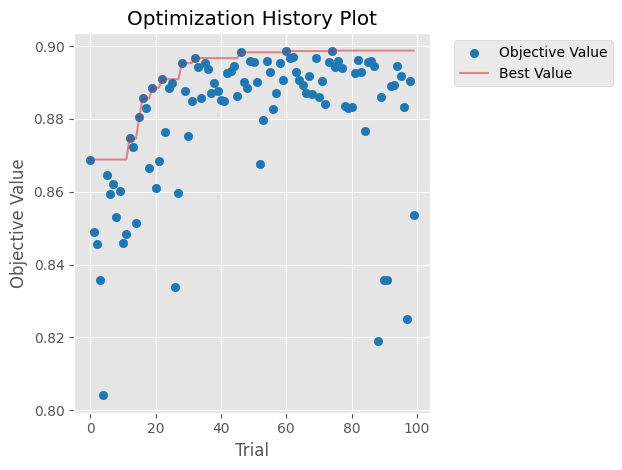

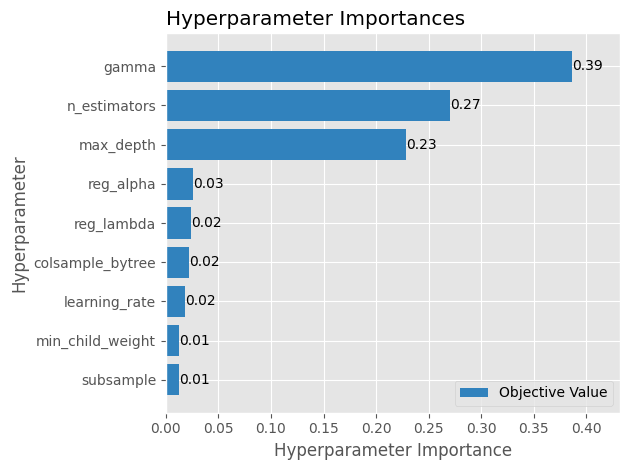

In [8]:
# pip install optuna  (if needed)
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
        'device': 'cuda',
        'tree_method': 'hist'
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        xgb.XGBClassifier(**params), X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(multivariate=True)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best AUC (CV): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Visualize search
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout(); plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()

## 8. Train Final XGBoost Model

Uses Optuna's best params if tuning was run, otherwise falls back to manually tuned defaults.
Early stopping watches the test set logloss and halts when it stops improving.

In [9]:
# Use Optuna best params if available, else fall back to defaults
try:
    best_params = study.best_params
    print("Using Optuna best params")
except NameError:
    best_params = {
        'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,
        'reg_alpha': 0.1, 'reg_lambda': 1.0, 'gamma': 0,
    }
    print("Using default params (run Optuna cell first for best results)")

model = xgb.XGBClassifier(
    **best_params,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)
print(f"\nBest iteration: {model.best_iteration}")

Using Optuna best params
[0]	validation_0-logloss:0.68358	validation_1-logloss:0.68643
[50]	validation_0-logloss:0.45965	validation_1-logloss:0.54268
[100]	validation_0-logloss:0.37079	validation_1-logloss:0.49886
[150]	validation_0-logloss:0.31543	validation_1-logloss:0.47550
[200]	validation_0-logloss:0.27185	validation_1-logloss:0.45692
[250]	validation_0-logloss:0.23274	validation_1-logloss:0.44212
[300]	validation_0-logloss:0.20100	validation_1-logloss:0.42997
[350]	validation_0-logloss:0.17465	validation_1-logloss:0.41966
[400]	validation_0-logloss:0.14938	validation_1-logloss:0.40904
[450]	validation_0-logloss:0.12951	validation_1-logloss:0.40038
[500]	validation_0-logloss:0.11306	validation_1-logloss:0.39635
[550]	validation_0-logloss:0.09853	validation_1-logloss:0.39224
[600]	validation_0-logloss:0.08574	validation_1-logloss:0.38781
[650]	validation_0-logloss:0.07538	validation_1-logloss:0.38569
[700]	validation_0-logloss:0.06624	validation_1-logloss:0.38408
[750]	validation_0

## 9. Training Curves

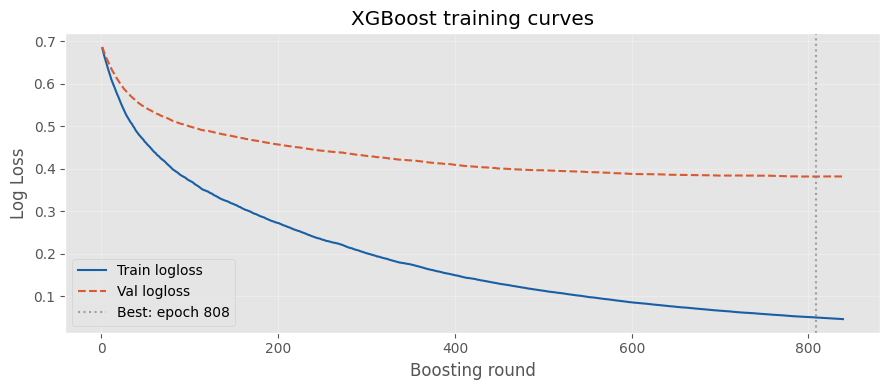

In [10]:
results_dict = model.evals_result()
train_logloss = results_dict['validation_0']['logloss']
val_logloss   = results_dict['validation_1']['logloss']
epochs = range(1, len(train_logloss) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, train_logloss, label='Train logloss', color='#185FA5')
plt.plot(epochs, val_logloss,   label='Val logloss',   color='#D85A30', linestyle='--')
plt.axvline(model.best_iteration, color='gray', linestyle=':', alpha=0.7, label=f'Best: epoch {model.best_iteration}')
plt.xlabel('Boosting round'); plt.ylabel('Log Loss')
plt.title('XGBoost training curves'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluation — Balanced vs Natural Distribution

We report two AUC numbers:
- **Balanced AUC** — measured on the swapped 50/50 test set. Good for comparing model versions.
- **Natural AUC** — measured on the unswapped test set (fighter 1 always the favorite). This is the honest number to report externally — it reflects real-world fight conditions.

We also plot a **calibration curve**: if your model says 70%, does the fighter actually win 70% of the time? A well-calibrated model is essential for the edge-finding use case.

BALANCED TEST SET (50/50 after swap)
Accuracy : 0.8314
AUC      : 0.9114

               precision    recall  f1-score   support

Opponent wins       0.83      0.84      0.83      1272
 Fighter wins       0.83      0.83      0.83      1272

     accuracy                           0.83      2544
    macro avg       0.83      0.83      0.83      2544
 weighted avg       0.83      0.83      0.83      2544

NATURAL DISTRIBUTION (real fight ordering)
Accuracy : 0.8204
AUC      : 0.9018  ← report this one
Baseline : 0.5036  (naive always-pick-favorite accuracy)

               precision    recall  f1-score   support

Underdog wins       0.81      0.83      0.82       619
Favorite wins       0.83      0.81      0.82       628

     accuracy                           0.82      1247
    macro avg       0.82      0.82      0.82      1247
 weighted avg       0.82      0.82      0.82      1247



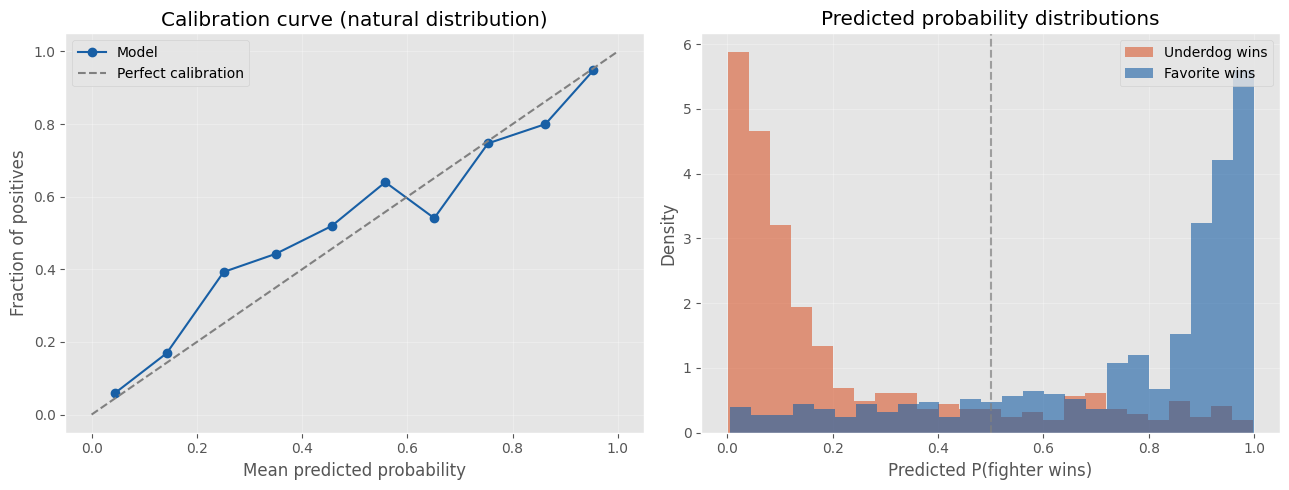

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

print('=' * 50)
print('BALANCED TEST SET (50/50 after swap)')
print('=' * 50)
print(f'Accuracy : {accuracy_score(y_test, preds):.4f}')
print(f'AUC      : {roc_auc_score(y_test, probs):.4f}')
print()
print(classification_report(y_test, preds, target_names=['Opponent wins', 'Fighter wins']))

# ── Natural distribution AUC ─────────────────────────────────────────────────
# Re-extract test rows from unswapped paired data using the same indice

probs_natural = model.predict_proba(X_test_natural)[:, 1]
preds_natural = (probs_natural > 0.5).astype(int)

print('=' * 50)
print('NATURAL DISTRIBUTION (real fight ordering)')
print('=' * 50)
print(f'Accuracy : {accuracy_score(y_test_natural, preds_natural):.4f}')
print(f'AUC      : {roc_auc_score(y_test_natural, probs_natural):.4f}  ← report this one')
print(f'Baseline : {y_test_natural.mean():.4f}  (naive always-pick-favorite accuracy)')
print()
print(classification_report(y_test_natural, preds_natural, target_names=['Underdog wins', 'Favorite wins']))

# ── Calibration curve ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration on natural test set
prob_true, prob_pred = calibration_curve(y_test_natural, probs_natural, n_bins=10)
axes[0].plot(prob_pred, prob_true, 'o-', color='#185FA5', label='Model')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[0].set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
            title='Calibration curve (natural distribution)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Probability distribution
axes[1].hist(probs_natural[y_test_natural == 0], bins=25, alpha=0.6,
             color='#D85A30', label='Underdog wins', density=True)
axes[1].hist(probs_natural[y_test_natural == 1], bins=25, alpha=0.6,
             color='#185FA5', label='Favorite wins', density=True)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set(xlabel='Predicted P(fighter wins)', ylabel='Density',
            title='Predicted probability distributions')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Optional: fit isotonic calibration if curve is S-shaped ──────────────────
# Uncomment if calibration curve deviates significantly from diagonal:
# calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
# calibrated_model.fit(X_test_natural, y_test_natural)  # use a held-out cal set ideally

## 11. Feature Importance (SHAP)

SHAP values show the actual contribution of each feature to individual predictions — more reliable than XGBoost's built-in importance.

Top 20 most important features:
                                           feature  mean_abs_shap
                                         diff_wins       0.558857
                                       diff_losses       0.347358
        diff_significant_strikes_landed_per_minute       0.290848
                                   opp_career_wins       0.260622
                                       career_wins       0.250397
                                    close_odds_opp       0.189538
                                     career_losses       0.170317
                                 opp_career_losses       0.165126
                                          diff_age       0.132525
      diff_significant_strikes_absorbed_per_minute       0.129666
                                   close_odds_self       0.125456
                                   diff_close_odds       0.125154
                diff_significant_striking_accuracy       0.116188
      career_significant_strikes_landed_per_

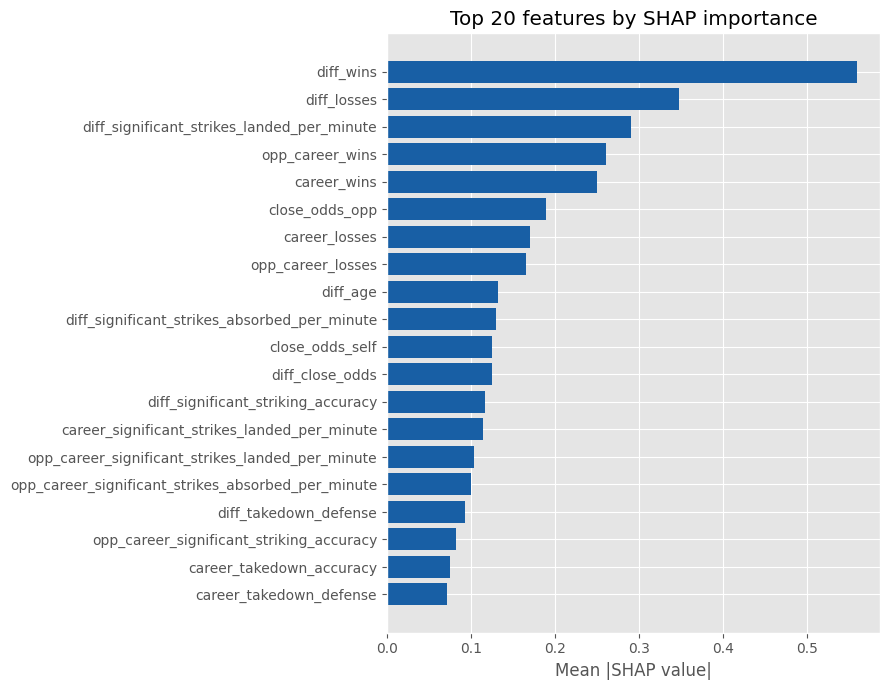

In [12]:
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test)

importance = pd.DataFrame({
    'feature':        feature_cols,
    'mean_abs_shap':  np.abs(shap_vals).mean(0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 20 most important features:")
print(importance.head(20).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 7))
top20 = importance.head(20)
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1], color='#185FA5')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features by SHAP importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Predict Any Matchup

Works for any two fighters in the database — including hypothetical matchups that never happened.

Inference averages both orderings (A vs B and B vs A) so probabilities always sum to exactly 1.0.

In [13]:
def _build_row(fighter_name, opponent_name, open_odds=np.nan, close_odds=np.nan, opponent_open_odds=np.nan, opponent_close_odds=np.nan, odds_inferred=1):
    """
    Build a single feature row for a fighter vs opponent matchup.
    Uses the fighter's most recent rolling stats + career stats.
    Returns a DataFrame aligned to feature_cols, or None if not found.
    """
    fn = clean_name(fighter_name)
    on = clean_name(opponent_name)

    if fn not in fl_model['FIGHTER'].values:
        print(f"'{fighter_name}' not found in fight history.")
        return None
    if on not in fs['name'].values:
        print(f"'{opponent_name}' not found in fighter database.")
        return None

    # Most recent rolling stats for the fighter
    fighter_row = fl_model[fl_model['FIGHTER'] == fn].iloc[-1]

    # Most recent rolling stats for the opponent (if they have fight history)
    if on in fl_model['FIGHTER'].values:
        opp_row = fl_model[fl_model['FIGHTER'] == on].iloc[-1]
        opp_rolling = {f'{c}_opp': opp_row[c] for c in roll_cols}
    else:
        # Opponent has no fight history — use zeros for rolling stats
        opp_rolling = {f'{c}_opp': 0.0 for c in roll_cols}

    # Career stats
    career_self_row = fs[fs['name'] == fn].iloc[0]
    career_opp_row  = fs[fs['name'] == on].iloc[0]

    row = {}
    for c in roll_cols:
        row[f'{c}_self'] = fighter_row[c]
    row['open_odds_self'] = open_odds
    row['close_odds_self'] = close_odds
    row.update(opp_rolling)
    row['open_odds_opp'] = opponent_open_odds
    row['close_odds_opp'] = opponent_close_odds
    row['odds_inferred'] = odds_inferred
    for c in career_cols:
        row[f'career_{c}']     = career_self_row[c]
        row[f'opp_career_{c}'] = career_opp_row[c]

    # Diff features
    for c in roll_cols + ['open_odds', 'close_odds']:
        row[f'diff_{c}'] = row[f'{c}_self'] - row[f'{c}_opp']
    for s, o in zip(career_self, career_opp):
        row[f'diff_{s[7:]}'] = row[s] - row[o]

    return pd.DataFrame([row])[feature_cols]


def predict_fight(
    fighter1: str,
    fighter2: str,
    fighter1_open_odds=np.nan,
    fighter2_open_odds=np.nan,
    fighter1_close_odds=np.nan,
    fighter2_close_odds=np.nan,
    odds_inferred: int = 1,
    verbose: bool = True,
):
    """
    Predict the outcome of a fight between two fighters.

    Averages predictions from both orderings (f1 vs f2 and f2 vs f1)
    so output probabilities are symmetric and always sum to 1.0.

    Returns (winner_name, win_probability) or None if fighters not found.
    """
    row_ab = _build_row(fighter1, fighter2, fighter1_open_odds, fighter1_close_odds, fighter2_open_odds, fighter2_close_odds, odds_inferred)
    row_ba = _build_row(fighter2, fighter1, fighter2_open_odds, fighter2_close_odds, fighter1_open_odds, fighter1_close_odds, odds_inferred)
    if row_ab is None or row_ba is None:
        return None

    p_ab = model.predict_proba(row_ab)[0, 1]  # P(fighter1 wins | fighter1=self)
    p_ba = model.predict_proba(row_ba)[0, 1]  # P(fighter2 wins | fighter2=self)

    # Average both orderings — guaranteed to sum to 1.0
    prob_f1 = (p_ab + (1 - p_ba)) / 2

    winner   = fighter1 if prob_f1 > 0.5 else fighter2
    win_prob = prob_f1  if prob_f1 > 0.5 else 1 - prob_f1

    if verbose:
        bar_len = 30
        f1_bar = int(prob_f1 * bar_len)
        f2_bar = bar_len - f1_bar
        print(f"\n{'='*52}")
        print(f"  {fighter1:<22} vs.  {fighter2}")
        print(f"{'='*52}")
        print(f"  {'█' * f1_bar}{'░' * f2_bar}")
        print(f"  P({fighter1} wins) : {prob_f1:.1%}")
        print(f"  P({fighter2} wins) : {1-prob_f1:.1%}")
        print(f"  Predicted winner  : {winner} ({win_prob:.1%})")
        print(f"  Sum check         : {prob_f1 + (1-prob_f1):.3f}  ✓")

    return winner, win_prob


# ── Try some fights ───────────────────────────────────────────────────────────
predict_fight("Jon Jones", "Stipe Miocic")
predict_fight("Islam Makhachev", "Charles Oliveira")
predict_fight("Alex Pereira", "Magomed Ankalaev")
predict_fight("Paddy Pimblett", "Justin Gaethje")   # hypothetical


  Jon Jones              vs.  Stipe Miocic
  █████████████████████████████░
  P(Jon Jones wins) : 99.2%
  P(Stipe Miocic wins) : 0.8%
  Predicted winner  : Jon Jones (99.2%)
  Sum check         : 1.000  ✓

  Islam Makhachev        vs.  Charles Oliveira
  ███████████████████████░░░░░░░
  P(Islam Makhachev wins) : 77.9%
  P(Charles Oliveira wins) : 22.1%
  Predicted winner  : Islam Makhachev (77.9%)
  Sum check         : 1.000  ✓

  Alex Pereira           vs.  Magomed Ankalaev
  ██████████████░░░░░░░░░░░░░░░░
  P(Alex Pereira wins) : 49.9%
  P(Magomed Ankalaev wins) : 50.1%
  Predicted winner  : Magomed Ankalaev (50.1%)
  Sum check         : 1.000  ✓

  Paddy Pimblett         vs.  Justin Gaethje
  ████████░░░░░░░░░░░░░░░░░░░░░░
  P(Paddy Pimblett wins) : 26.9%
  P(Justin Gaethje wins) : 73.1%
  Predicted winner  : Justin Gaethje (73.1%)
  Sum check         : 1.000  ✓


('Justin Gaethje', np.float32(0.7305435))

In [ ]:
predict_fight("Clayton Carpenter", "Jose Ochoa")


  Clayton Carpenter      vs.  Jose Ochoa
  ████████████████░░░░░░░░░░░░░░
  P(Clayton Carpenter wins) : 54.2%
  P(Jose Ochoa wins) : 45.8%
  Predicted winner  : Clayton Carpenter (54.2%)
  Sum check         : 1.000  ✓


('Clayton Carpenter', np.float32(0.54215145))

## 13. Symmetry Check

Verify that `predict_fight(A, B)` and `predict_fight(B, A)` give consistent, complementary results.

In [14]:
def symmetry_check(a, b):
    r_ab = _build_row(a, b)
    r_ba = _build_row(b, a)
    p_ab = model.predict_proba(r_ab)[0, 1]
    p_ba = model.predict_proba(r_ba)[0, 1]
    prob_a = (p_ab + (1 - p_ba)) / 2
    print(f"{a} vs {b}")
    print(f"  P({a} wins, A listed first) : {prob_a:.3f}")
    print(f"  P({a} wins, A listed second): {(p_ba + (1 - p_ab)) / 2:.3f}  ← should match")
    print(f"  Sum: {prob_a + (1 - prob_a):.3f}  ✓\n")

symmetry_check("Jon Jones", "Stipe Miocic")
symmetry_check("Islam Makhachev", "Charles Oliveira")
symmetry_check("Alex Pereira", "Magomed Ankalaev")

Jon Jones vs Stipe Miocic
  P(Jon Jones wins, A listed first) : 0.992
  P(Jon Jones wins, A listed second): 0.008  ← should match
  Sum: 1.000  ✓

Islam Makhachev vs Charles Oliveira
  P(Islam Makhachev wins, A listed first) : 0.779
  P(Islam Makhachev wins, A listed second): 0.221  ← should match
  Sum: 1.000  ✓

Alex Pereira vs Magomed Ankalaev
  P(Alex Pereira wins, A listed first) : 0.499
  P(Alex Pereira wins, A listed second): 0.501  ← should match
  Sum: 1.000  ✓



## 14. List Available Fighters

In [15]:
all_fighters = sorted(fl_model['FIGHTER'].unique())
print(f"Fighters with fight history: {len(all_fighters)}")
print("\nSample:", all_fighters[:20])

# Search for a fighter
def search_fighters(query):
    q = query.lower()
    matches = [f for f in all_fighters if q in f]
    print(f"Matches for '{query}': {matches[:10]}")

search_fighters("jones")
search_fighters("makhachev")

Fighters with fight history: 2264

Sample: ['aalon cruz', 'aaron phillips', 'aaron pico', 'aaron riley', 'aaron rosa', 'aaron simpson', 'abdul rakhman yakhyaev', 'abdul razak alhassan', 'abdul-kareem al-selwady', 'abel trujillo', 'abu azaitar', 'abubakar nurmagomedov', 'abus magomedov', 'adam fugitt', 'adam milstead', 'adam wieczorek', 'adlan amagov', 'adrian yanez', 'adriano martins', 'aiemann zahabi']
Matches for 'jones': ['jocelyn jones-lybarger', 'jon jones', 'justin jones', 'mason jones', 'paul jones', 'trevin jones']
Matches for 'makhachev': ['islam makhachev']


## 15. Save & Load Model

In [16]:
# Save everything needed for inference
model.save_model('xgb_fight_model.json')
with open('paired_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
with open('fighter_stats_clean.pkl', 'wb') as f:
    pickle.dump(fs, f)
with open('fl_model_final.pkl', 'wb') as f:
    pickle.dump(fl_model, f)
print("Saved: xgb_fight_model.json, paired_feature_cols.pkl, fighter_stats_clean.pkl, fl_model_final.pkl")

# ── Reload ────────────────────────────────────────────────────────────────────
loaded_model = xgb.XGBClassifier()
loaded_model.load_model('xgb_fight_model.json')

with open('paired_feature_cols.pkl', 'rb') as f: loaded_feature_cols = pickle.load(f)
with open('fighter_stats_clean.pkl', 'rb') as f: loaded_fs = pickle.load(f)
with open('fl_model_final.pkl',      'rb') as f: loaded_fl = pickle.load(f)

print(f"\nModel reloaded. Features: {len(loaded_feature_cols)}")
print("Ready to predict.")

Saved: xgb_fight_model.json, paired_feature_cols.pkl, fighter_stats_clean.pkl, fl_model_final.pkl

Model reloaded. Features: 172
Ready to predict.
